# Blindspot · GRPO Training & Analysis (Colab + A100)

End-to-end training notebook for the **Blindspot** OpenEnv. Trains
**Qwen3.5-9B (bf16 LoRA via Unsloth)** with TRL's `GRPOTrainer`
against rewards computed by a live HTTP env server.

This notebook is split into 4 sections:

1. **Setup** — install deps, clone repo, boot env, sanity checks.
2. **Pre-training analysis** — explore the dataset (users, concepts,
   reading paths, comprehension lifts), then run *all* baselines and
   plot them so we have the "before" picture.
3. **Training** — load model, build prompts/reward, run GRPO, log live
   reward curves with running statistics.
4. **Post-training analysis** — evaluate the trained policy across all
   users with multiple seeds; plot trained-vs-baselines, per-component
   reward breakdown, per-user lift, action-type distribution, and
   qualitative sample episodes.

Estimated cost on A100: ~1.5–3 hours wall time, ~33 compute units.

---
## 1. Setup

In [1]:
%%bash
set -e
# Colab-safe setup for Qwen3.5 + Unsloth RL.
# If a previous attempt already broke torch/CUDA in this runtime, click Runtime > Restart session first.
python -m pip uninstall -y unsloth unsloth_zoo transformers trl datasets torchcodec >/dev/null 2>&1 || true
python -m pip install -q --upgrade pip wheel setuptools packaging
python -m pip install -q --upgrade --no-cache-dir \
  'openenv-core[core]' \
  'transformers==5.5.0' \
  'trl==0.24.0' \
  'datasets==4.3.0' \
  'numpy<2.1' \
  'torchao>=0.16.0' \
  peft accelerate bitsandbytes
python -m pip install -q --upgrade --no-cache-dir --no-deps \
  'unsloth_zoo==2026.4.9' \
  'unsloth==2026.4.8'
python - <<'PY'
import torch, transformers, trl, datasets
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
print(f'torch={torch.__version__} cuda={torch.version.cuda}')
print(f'transformers={transformers.__version__} trl={trl.__version__} datasets={datasets.__version__}')
if 'qwen3_5' not in CONFIG_MAPPING:
    raise SystemExit('Transformers 5.5.0 loaded, but qwen3_5 is missing. Click Runtime > Restart session and rerun this cell.')
print('qwen3_5 support OK')
PY

torch=2.10.0+cu128 cuda=12.8
transformers=5.5.0 trl=0.24.0 datasets=4.3.0
qwen3_5 support OK


In [2]:
%%bash
set -e
# Clone the project (idempotent) and boot the env server in the background.
git clone https://github.com/vasarlalikhilavinash/blindspot-env 2>/dev/null || (cd blindspot-env && git pull)
cd blindspot-env
for f in \
  data/user_summaries.json \
  data/user_splits.json \
  data/concept_catalog.json \
  data/concept_pool_per_user.json \
  data/ground_truth_adoption.json \
  data/comprehension_scores.json \
  data/reading_paths.json \
  data/novelty_flags.json; do
  test -f "$f" || { echo "Missing required real-data artifact: $f" >&2; exit 1; }
done
mkdir -p plots training/checkpoints

# Kill any stale server from a previous run
pkill -f "uvicorn server.app:app" 2>/dev/null || true
sleep 1

# Start fresh
nohup uvicorn server.app:app --host 0.0.0.0 --port 8000 --log-level warning > /tmp/blindspot.log 2>&1 &

# Wait up to 30s for the server to respond
for i in $(seq 1 30); do
  if curl -sf http://localhost:8000/state > /dev/null 2>&1; then
    echo "✓ env server ready (${i}s)"
    curl -s http://localhost:8000/state | head -c 300
    exit 0
  fi
  sleep 1
done
echo "ERROR: server did not start within 30s. Check /tmp/blindspot.log:" >&2
cat /tmp/blindspot.log >&2
exit 1

Updating 76a35c7..305defc
Fast-forward
 notebooks/02_training.ipynb        | 2 ++
 scripts/build_training_notebook.py | 2 ++
 2 files changed, 4 insertions(+)
✓ env server ready (5s)
{"episode_id":"faf4b42d-281e-40e5-bb56-9536d7c9a39b","step_count":0}

From https://github.com/vasarlalikhilavinash/blindspot-env
   76a35c7..305defc  main       -> origin/main


In [3]:
import sys, requests, json
sys.path.insert(0, 'blindspot-env')
ENV_URL = 'http://localhost:8000'

# Sanity check: env reachable, dataset shape OK
r = requests.post(f'{ENV_URL}/reset', json={}).json()
obs = r.get('observation', r) or {}
print(f"✓ env reachable")
print(f"  user pool size : {len(obs.get('user_id_pool', []))}")
print(f"  candidates    : {len(obs.get('candidate_concepts', []))}")

✓ env reachable
  user pool size : 17
  candidates    : 39


---
## 2. Pre-training analysis

Inspect the data the env was built on. This is the same pre-computed
artifact set that powers the reward function during training.

In [4]:
import json, statistics
from pathlib import Path

DATA = Path('blindspot-env/data')

users = json.load(open(DATA/'user_summaries.json'))
catalog = json.load(open(DATA/'concept_catalog.json'))
pool = json.load(open(DATA/'concept_pool_per_user.json'))
adoption = json.load(open(DATA/'ground_truth_adoption.json'))
comp = json.load(open(DATA/'comprehension_scores.json'))
paths = json.load(open(DATA/'reading_paths.json'))
nov = json.load(open(DATA/'novelty_flags.json'))

stats = {
    'n_users': len(users),
    'n_concepts_total': len(catalog),
    'n_concepts_in_pool': len({c for v in pool.values() for c in v}),
    'n_reading_paths': len(paths),
    'n_novel_flagged': sum(1 for v in nov.values() if v),
    'n_adoption_pairs': sum(len(v) for v in adoption.values()),
    'n_comprehension_pairs': sum(len(v) for v in comp.values()),
    'pool_size_per_user_mean': round(statistics.mean(len(v) for v in pool.values()), 1),
    'adoption_per_user_mean': round(statistics.mean(len(v) for v in adoption.values()), 1),
    'comprehension_lift_mean': round(statistics.mean(
        l for v in comp.values() for l in v.values()) or 0, 3) if any(v for v in comp.values()) else 0,
}
import pandas as pd
display(pd.DataFrame(list(stats.items()), columns=['stat', 'value']).style.hide(axis='index'))

stat,value
n_users,17.000000
n_concepts_total,1168.000000
n_concepts_in_pool,282.000000
n_reading_paths,282.000000
n_novel_flagged,968.000000
n_adoption_pairs,62.000000
n_comprehension_pairs,23.000000
pool_size_per_user_mean,38.500000
adoption_per_user_mean,3.600000
comprehension_lift_mean,0.181000


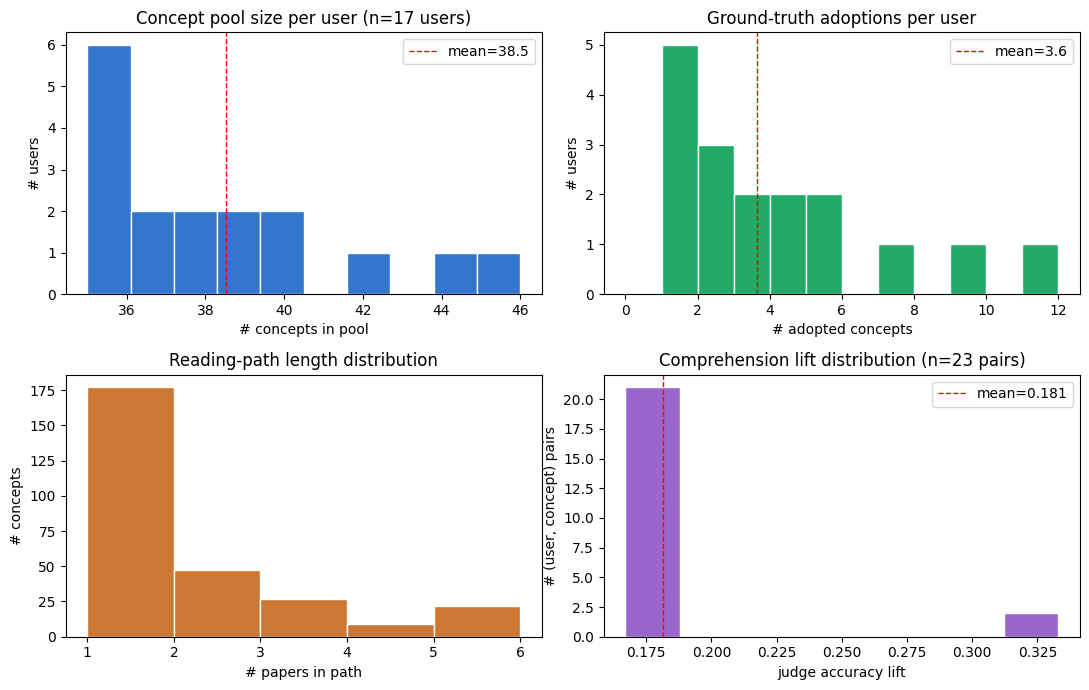

In [5]:
# Distribution plots: pool sizes, adoption per user, path lengths, comprehension lifts
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

ax = axes[0, 0]
sizes = [len(v) for v in pool.values()]
ax.hist(sizes, bins=10, color='#3377cc', edgecolor='white')
ax.set_title(f'Concept pool size per user (n={len(pool)} users)')
ax.set_xlabel('# concepts in pool'); ax.set_ylabel('# users')
ax.axvline(np.mean(sizes), color='red', ls='--', lw=1, label=f'mean={np.mean(sizes):.1f}')
ax.legend()

ax = axes[0, 1]
adopt_counts = [len(v) for v in adoption.values()]
ax.hist(adopt_counts, bins=range(0, max(adopt_counts)+2), color='#22aa66', edgecolor='white')
ax.set_title('Ground-truth adoptions per user')
ax.set_xlabel('# adopted concepts'); ax.set_ylabel('# users')
ax.axvline(np.mean(adopt_counts), color='red', ls='--', lw=1, label=f'mean={np.mean(adopt_counts):.1f}')
ax.legend()

ax = axes[1, 0]
plens = [len(p) for p in paths.values()]
ax.hist(plens, bins=range(1, max(plens)+2), color='#cc7733', edgecolor='white')
ax.set_title('Reading-path length distribution')
ax.set_xlabel('# papers in path'); ax.set_ylabel('# concepts')

ax = axes[1, 1]
lifts = [l for v in comp.values() for l in v.values()]
if lifts:
    ax.hist(lifts, bins=8, color='#9966cc', edgecolor='white')
    ax.set_title(f'Comprehension lift distribution (n={len(lifts)} pairs)')
    ax.set_xlabel('judge accuracy lift'); ax.set_ylabel('# (user, concept) pairs')
    ax.axvline(np.mean(lifts), color='red', ls='--', lw=1, label=f'mean={np.mean(lifts):.3f}')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'no lift data', ha='center', va='center')
    ax.set_title('Comprehension lifts')

plt.tight_layout()
plt.savefig('blindspot-env/plots/data_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

/content/blindspot-env
Wrote plots to /content/blindspot-env/plots/
                  Random  total=+0.088  std=1.404
                Trending  total=+0.212  std=0.510
         Dense Retrieval  total=+0.467  std=1.201
    Oracle (upper bound)  total=+3.286  std=3.588
/content


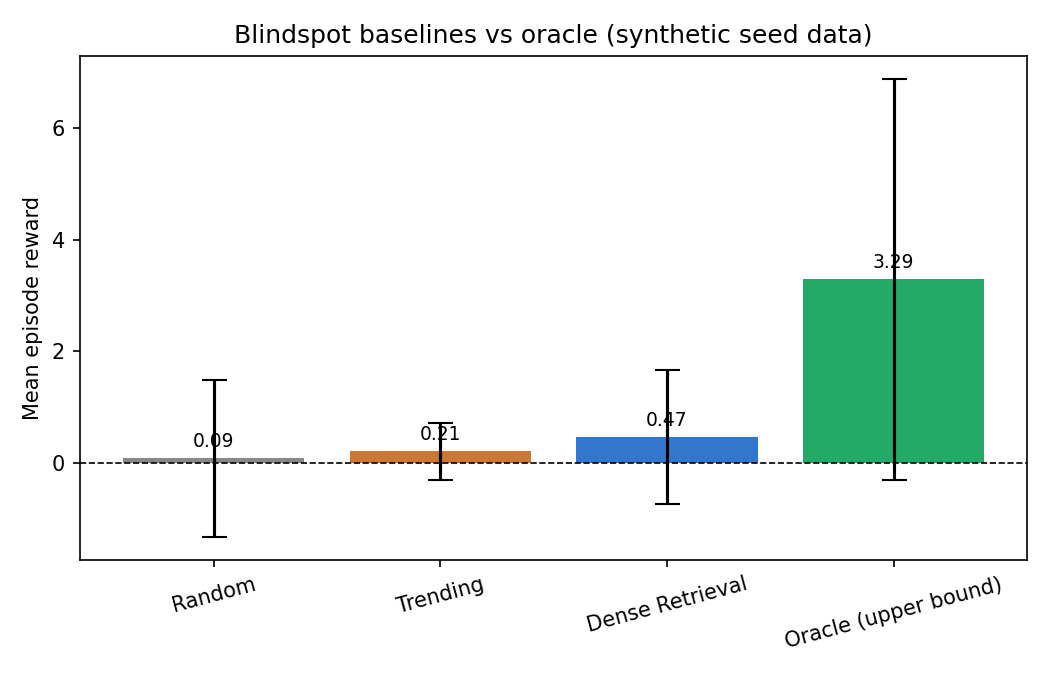

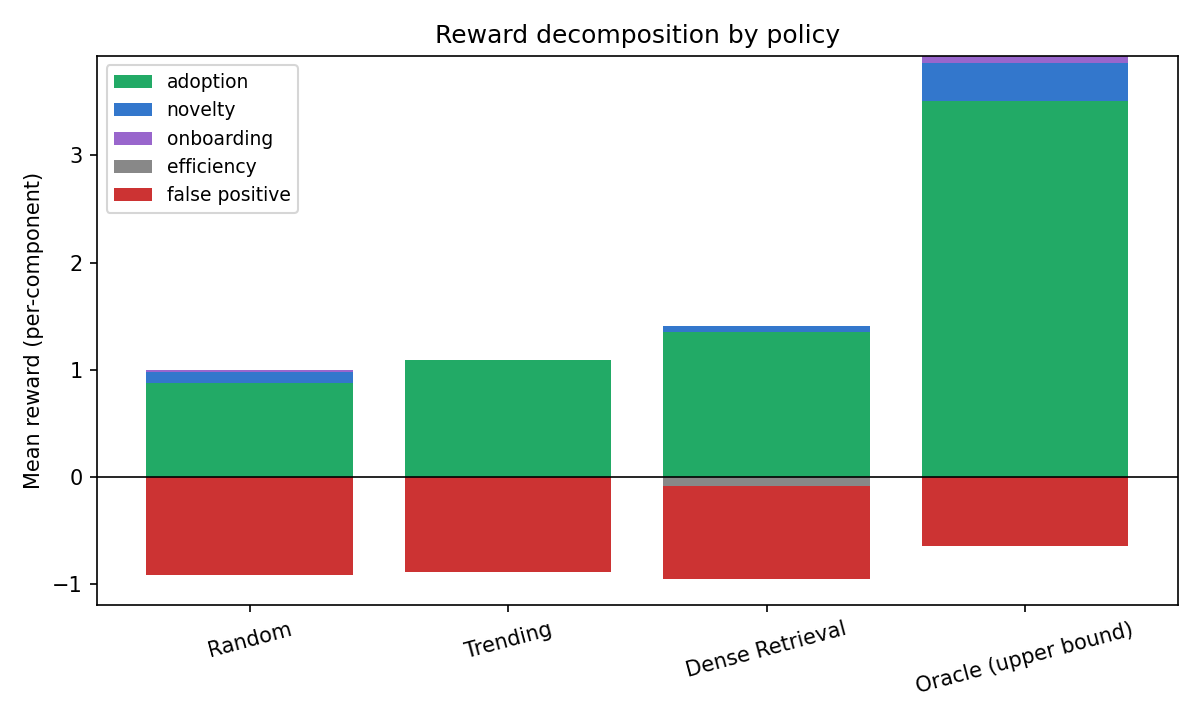


Pre-training baseline rewards (mean ± std):
  Random                    +0.088 ± 1.40
  Trending                  +0.212 ± 0.51
  Dense Retrieval           +0.467 ± 1.20
  Oracle (upper bound)      +3.286 ± 3.59


In [6]:
# Run all baselines + oracle on the live env (these are the "before" numbers).
%cd blindspot-env
!python scripts/make_plots.py 2>&1 | tail -20
%cd ..

from IPython.display import Image, display
display(Image('blindspot-env/plots/baseline_comparison.png'))
display(Image('blindspot-env/plots/reward_decomposition.png'))

# Persist the pre-training summary so we can compare against trained policy
import json, shutil
shutil.copyfile('blindspot-env/plots/summary.json', 'blindspot-env/plots/summary_pretraining.json')
pretrain = json.load(open('blindspot-env/plots/summary_pretraining.json'))
print('\nPre-training baseline rewards (mean ± std):')
for b in pretrain:
    print(f"  {b['name']:25s} {b['total']:+.3f} ± {b['std']:.2f}")

---
## 3. Training

Load the base model, attach LoRA adapters, build the prompt
dataset, and run GRPO with `num_generations=8` per prompt.

In [7]:
import importlib as _il
import importlib.metadata as importlib_metadata
import importlib.metadata as _imeta
import importlib.util as _ilu
import os
import pathlib as _pl
import sys
import tempfile as _tf
import types as _types

import numpy as np
import torch

loaded_numpy = np.__version__
installed_numpy = importlib_metadata.version('numpy')
if loaded_numpy != installed_numpy:
    raise RuntimeError(
        f'numpy was upgraded during setup (loaded={loaded_numpy}, installed={installed_numpy}). '
        'Click Runtime > Restart session, then rerun from the top.'
    )

# torchcodec is baked into the Colab base image as a broken package (incompatible with torch 2.11).
# datasets also checks sys.modules for 'torchcodec' and imports torchcodec.decoders if found.
# Stub ALL torchcodec submodules so nothing tries to dlopen the broken .so files.
try:
    _imeta.version('torchcodec')
except _imeta.PackageNotFoundError:
    _fake_base = _pl.Path(_tf.mkdtemp())
    _di = _fake_base / 'torchcodec-0.0.0.dist-info'
    _di.mkdir()
    (_di / 'METADATA').write_text('Metadata-Version: 2.1\nName: torchcodec\nVersion: 0.0.0\n')
    (_di / 'RECORD').write_text('')
    sys.path.insert(0, str(_fake_base))
    _il.invalidate_caches()

for _n in (
    'torchcodec',
    'torchcodec._core',
    'torchcodec._core.ops',
    'torchcodec.decoders',
):
    _m = sys.modules.get(_n)
    if _m is None:
        _m = _types.ModuleType(_n)
        sys.modules[_n] = _m
    if getattr(_m, '__spec__', None) is None:
        _m.__spec__ = _ilu.spec_from_loader(_n, loader=None)
    _m.__path__ = []  # mark as package so submodule imports don't raise TypeError

# Dummy classes datasets imports from torchcodec.decoders
sys.modules['torchcodec.decoders'].AudioDecoder = type('AudioDecoder', (), {})
sys.modules['torchcodec.decoders'].VideoDecoder = type('VideoDecoder', (), {})
sys.modules['torchcodec'].load_torchcodec_shared_libraries = lambda: None

del _n, _m, _il, _imeta, _ilu, _pl, _tf, _types

import unsloth
from unsloth import FastLanguageModel
from transformers.models.auto.configuration_auto import CONFIG_MAPPING

if 'qwen3_5' not in CONFIG_MAPPING:
    raise RuntimeError('Old Transformers without qwen3_5 support. Click Runtime > Restart session and rerun the setup cell.')

BASE_MODEL = os.environ.get('BASE_MODEL', 'unsloth/Qwen3.5-9B')
FALLBACK_BASE_MODEL = os.environ.get('FALLBACK_BASE_MODEL', 'unsloth/Qwen3.5-4B')
MAX_SEQ_LENGTH = 4096 + 128


def load_base_model(model_name):
    return FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=False,
        dtype=torch.bfloat16,
        fast_inference=False,
    )


try:
    model, tokenizer = load_base_model(BASE_MODEL)
    print(f'Loaded base model: {BASE_MODEL}')
except (RuntimeError, OSError) as exc:
    message = str(exc)
    missing_config = 'No config file found' in message or 'is not a local folder' in message
    unsupported_arch = 'qwen3_5' in message and ('does not support' in message or 'not recognize' in message)
    if unsupported_arch:
        raise RuntimeError('Transformers v5 is required for Qwen3.5. Click Runtime > Restart session and rerun the setup cell.') from exc
    if not missing_config or BASE_MODEL == FALLBACK_BASE_MODEL:
        raise
    print(f'Base model could not be loaded: {BASE_MODEL}')
    print(f'First error line: {message.splitlines()[0]}')
    BASE_MODEL = FALLBACK_BASE_MODEL
    print(f'Falling back to: {BASE_MODEL}')
    model, tokenizer = load_base_model(BASE_MODEL)

# Attach LoRA adapters so GRPO has trainable parameters
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)

if os.path.isdir('blindspot-env/training/checkpoints/sft'):
    model.load_adapter('blindspot-env/training/checkpoints/sft')
    print('attached SFT adapter')
FastLanguageModel.for_training(model)

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'GPU: {torch.cuda.get_device_name(0)} | free {free/1e9:.1f}/{total/1e9:.1f} GB')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Loaded base model: unsloth/Qwen3.5-9B
GPU: NVIDIA H100 80GB HBM3 | free 65.2/85.0 GB


In [8]:
# Build prompt dataset by sampling only train-split (user, seed) pairs from the env.
import sys, os
_bd = next(p for p in ['/content/blindspot-env', 'blindspot-env'] if os.path.isdir(p))
if _bd not in sys.path:
    sys.path.insert(0, _bd)
from training.grpo_train import SYSTEM_PROMPT, render_obs, parse_action
import json, requests, random
from datasets import Dataset

ENV_URL = 'http://localhost:8000'
r0 = requests.post(f'{ENV_URL}/reset', json={}).json()
user_pool = (r0.get('observation', r0) or {}).get('user_id_pool', [])
split = json.load(open('blindspot-env/data/user_splits.json'))
train_users = [u for u in split.get('train', []) if u in user_pool]
test_users = [u for u in split.get('test', []) if u in user_pool]
if not train_users or not test_users:
    raise RuntimeError(f'Bad train/test split: train={len(train_users)} test={len(test_users)} user_pool={len(user_pool)}')

rng = random.Random(0)
rows = []
for _ in range(256):
    uid = rng.choice(train_users); seed = rng.randrange(1_000_000)
    obs = requests.post(f'{ENV_URL}/reset', json={'user_id': uid, 'seed': seed}).json()
    obs = obs.get('observation', obs)
    rows.append({'prompt': [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': render_obs(obs)},
    ], 'user_id': uid, 'seed': seed, 'split': 'train'})
ds = Dataset.from_list(rows)
print(f'Built {len(ds)} prompts across {len(set(r["user_id"] for r in rows))}/{len(train_users)} train users')
print(f'Held-out users reserved for evaluation: {len(test_users)}')

Built 256 prompts across 13/13 train users
Held-out users reserved for evaluation: 4


In [9]:
# Reward function: roll out a short multi-step episode so GRPO learns session-level behavior.
# Also stash the breakdowns so we can chart per-component reward later.
import requests
import torch

REWARD_LOG = []
ROLLOUT_STEP_LIMIT = 8


def _post_env(endpoint, payload):
    resp = requests.post(f'{ENV_URL}/{endpoint}', json=payload, timeout=30)
    if resp.status_code == 422:
        return {'reward': -0.1, 'done': True}, {'done': True, 'reward_breakdown': {'total': -0.1}}
    resp.raise_for_status()
    body = resp.json()
    obs = body.get('observation', body) or {}
    return body, obs


# Unwrap multimodal Qwen2_5_VLProcessor -> inner text tokenizer to avoid load_image crash
from transformers import ProcessorMixin as _ProcessorMixin
_TXT_TOK = tokenizer.tokenizer if isinstance(tokenizer, _ProcessorMixin) else tokenizer


def _generate_completion(msgs):
    # apply_chat_template in transformers 5.x returns str; tokenize separately
    text = _TXT_TOK.apply_chat_template(
        msgs,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = _TXT_TOK(text, return_tensors='pt').input_ids.to(model.device)
    with torch.inference_mode():
        out = model.generate(inputs, max_new_tokens=64, do_sample=False, temperature=0.0)
    return _TXT_TOK.decode(out[0, inputs.shape[1]:], skip_special_tokens=True)


def run_episode(user_id, seed, first_completion=None, first_action=None, max_steps=ROLLOUT_STEP_LIMIT):
    payload = {}
    if user_id is not None:
        payload['user_id'] = user_id
    if seed is not None:
        payload['seed'] = seed

    _, obs = _post_env('reset', payload)
    msgs = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': render_obs(obs)},
    ]

    action_trace = []
    completion_trace = []
    invalid_streak = 0
    for step_idx in range(max_steps):
        if step_idx == 0 and first_completion is not None:
            text = first_completion
            action = first_action or parse_action(first_completion)
        else:
            text = _generate_completion(msgs)
            action = parse_action(text)

        if not action or 'type' not in action:
            if step_idx == 0:
                return -0.05, {}, [], [text or '']
            msgs.append({'role': 'assistant', 'content': text or ''})
            msgs.append({'role': 'user', 'content': 'Reply with EXACTLY one JSON command.'})
            invalid_streak += 1
            if invalid_streak >= 2:
                break
            continue

        result, obs = _post_env('step', {'action': action})
        invalid_streak = 0
        action_trace.append(action)
        completion_trace.append(text or '')
        msgs.append({'role': 'assistant', 'content': text or ''})
        if result.get('done') or obs.get('done'):
            br = obs.get('reward_breakdown') or {}
            total = float(br.get('total', result.get('reward', 0.0) or 0.0))
            return total, br, action_trace, completion_trace
        msgs.append({'role': 'user', 'content': render_obs(obs)})

    result, obs = _post_env('step', {'action': {'type': 'stop'}})
    br = obs.get('reward_breakdown') or {}
    total = float(br.get('total', result.get('reward', 0.0) or 0.0))
    action_trace.append({'type': 'stop'})
    completion_trace.append('{"type": "stop"}  # auto-stop after rollout limit')
    return total, br, action_trace, completion_trace


def reward_fn(prompts, completions, user_id=None, seed=None, **kw):
    out = []
    uids = user_id if isinstance(user_id, list) else [user_id] * len(completions)
    seeds = seed if isinstance(seed, list) else [seed] * len(completions)
    for _prompt_msgs, completion, uid, sd in zip(prompts, completions, uids, seeds):
        text = completion if isinstance(completion, str) else completion[-1].get('content', '')
        action = parse_action(text)
        if not action or 'type' not in action:
            out.append(-0.05)
            REWARD_LOG.append((-0.05, {}))
            continue
        total, br, _, _ = run_episode(uid, sd, first_completion=text, first_action=action)
        out.append(total)
        REWARD_LOG.append((total, br))
    return out

In [10]:
from trl import GRPOConfig, GRPOTrainer
from transformers import ProcessorMixin

# CRITICAL: Unsloth returns a multimodal Qwen2_5_VLProcessor for Qwen3.5, not a plain tokenizer.
# When TRL calls processing_class(text=prompts_text, return_tensors="pt"), the processor tries
# to load images from the text and crashes with UnidentifiedImageError. Pass the inner text
# tokenizer instead so the entire vision codepath is bypassed.
text_tokenizer = tokenizer.tokenizer if isinstance(tokenizer, ProcessorMixin) else tokenizer
print(f"processing_class type: {type(text_tokenizer).__name__}  (was {type(tokenizer).__name__})")

cfg = GRPOConfig(
    output_dir='blindspot-env/training/checkpoints/grpo',
    learning_rate=5e-6,
    max_steps=150,
    num_generations=4,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_prompt_length=2048,
    max_completion_length=64,
    logging_steps=5,
    save_steps=100,
    bf16=True,
    report_to='none',
)
trainer = GRPOTrainer(model=model, processing_class=text_tokenizer,
                      reward_funcs=[reward_fn], args=cfg, train_dataset=ds)

print(f'Starting GRPO: {cfg.max_steps} steps × {cfg.num_generations} rollouts/step '
      f'= {cfg.max_steps*cfg.num_generations} reward queries')
import os; os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
import torch; torch.cuda.empty_cache()
trainer.train()
trainer.save_model('blindspot-env/training/checkpoints/grpo')
print('✓ training complete, adapter saved')


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.


processing_class type: TokenizersBackend  (was Qwen3VLProcessor)
Starting GRPO: 150 steps × 4 rollouts/step = 600 reward queries


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 256 | Num Epochs = 1 | Total steps = 150
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,097,984 of 9,438,911,728 (0.31% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Unsloth: Will smartly offload gradients to save VRAM!


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,0.000000,0.000000,0.000000,17.600000,15.200000,20.200000,0.000000,17.600000,15.200000,20.200000,0.000005,0.000000,0.000000
10,0.000000,-0.007500,0.010774,17.950000,15.400000,19.600000,0.000000,17.950000,15.400000,19.600000,0.000009,-0.007500,0.010774
15,0.000000,-0.005000,0.010000,17.800000,14.800000,20.800000,0.000000,17.800000,14.800000,20.800000,0.000060,-0.005000,0.010000
20,0.000000,-0.002500,0.005000,17.000000,15.400000,18.400000,0.000000,17.000000,15.400000,18.400000,0.000232,-0.002500,0.005000
25,0.000001,-0.002500,0.005000,19.050000,15.800000,21.800000,0.000000,19.050000,15.800000,21.800000,0.000930,-0.002500,0.005000
30,0.000004,-0.002500,0.005000,17.950000,14.600000,20.600000,0.000000,17.950000,14.600000,20.600000,0.003729,-0.002500,0.005000
35,0.000010,-0.002500,0.005000,16.250000,13.200000,19.400000,0.000000,16.250000,13.200000,19.400000,0.009807,-0.002500,0.005000
40,0.000001,-0.010000,0.020000,18.500000,15.800000,22.800000,0.000000,18.500000,15.800000,22.800000,0.000922,-0.010000,0.020000
45,0.000003,0.000000,0.000000,17.400000,15.000000,20.200000,0.000000,17.400000,15.000000,20.200000,0.002739,0.000000,0.000000
50,0.000006,0.000000,0.000000,16.100000,14.400000,18.000000,0.000000,16.100000,14.400000,18.000000,0.006161,0.000000,0.000000


Unsloth: Restored added_tokens_decoder metadata in blindspot-env/training/checkpoints/grpo/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in blindspot-env/training/checkpoints/grpo/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in blindspot-env/training/checkpoints/grpo/tokenizer_config.json.


✓ training complete, adapter saved


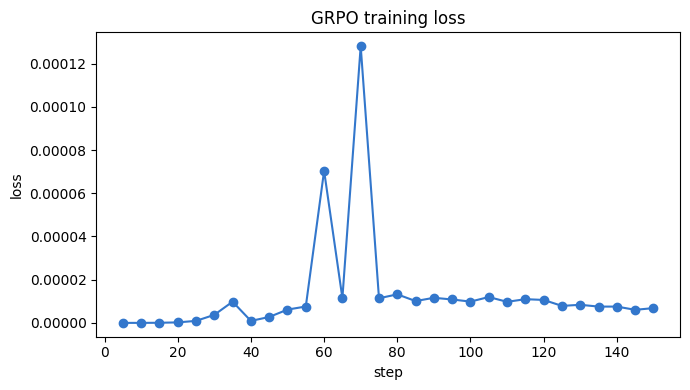

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.DataFrame(
    row for row in trainer.state.log_history
    if "loss" in row and "step" in row
)

if len(hist):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(hist["step"], hist["loss"], marker="o", lw=1.5, color="#3377cc")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.set_title("GRPO training loss")
    plt.tight_layout()
    plt.savefig("blindspot-env/plots/training_loss_curve.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No loss entries found in trainer.state.log_history")

---
## 4. Post-training analysis

Charts below quantify how much GRPO improved over the baselines.

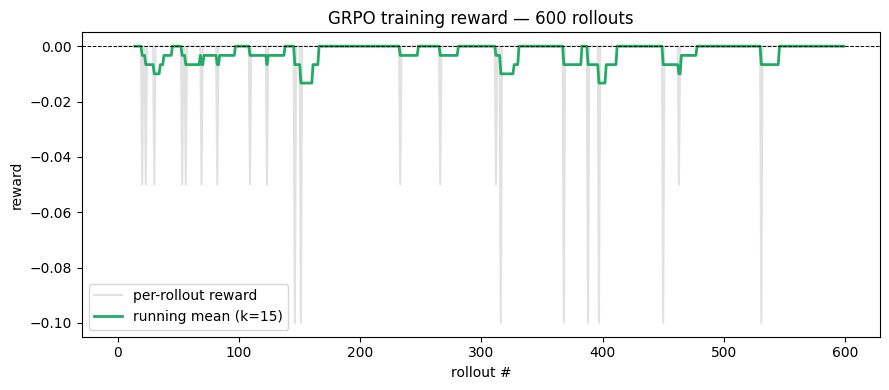

first 10% mean reward : -0.004
last  10% mean reward : +0.000
gain                  : +0.004


In [11]:
# 4.1 Live reward curve from training (running mean over rollouts).
import numpy as np
import matplotlib.pyplot as plt

totals = np.array([t for t, _ in REWARD_LOG])
window = max(1, len(totals)//40)
running = np.convolve(totals, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(totals, alpha=0.25, color='#888', label='per-rollout reward')
ax.plot(np.arange(len(running))+window-1, running, color='#22aa66', lw=2, label=f'running mean (k={window})')
ax.axhline(0, color='black', ls='--', lw=0.7)
ax.set_xlabel('rollout #'); ax.set_ylabel('reward')
ax.set_title(f'GRPO training reward — {len(totals)} rollouts')
ax.legend()
plt.tight_layout()
plt.savefig('blindspot-env/plots/training_reward_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'first 10% mean reward : {totals[:len(totals)//10].mean():+.3f}')
print(f'last  10% mean reward : {totals[-len(totals)//10:].mean():+.3f}')
print(f'gain                  : {totals[-len(totals)//10:].mean() - totals[:len(totals)//10].mean():+.3f}')

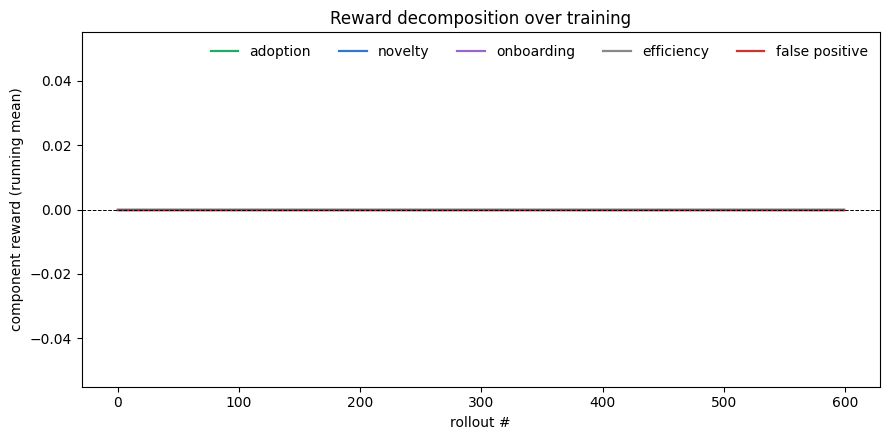

In [12]:
# 4.2 Per-component reward trajectory (adoption / novelty / onboarding / ...).
import pandas as pd
comp_rows = []
for i, (tot, br) in enumerate(REWARD_LOG):
    if not br: continue
    comp_rows.append({'step': i, **br})
if comp_rows:
    df = pd.DataFrame(comp_rows)
    cols = [c for c in ['adoption','novelty','onboarding','efficiency','false_positive'] if c in df.columns]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    w = max(1, len(df)//40)
    for c, color in zip(cols, ['#22aa66','#3377cc','#9966cc','#888888','#cc3333']):
        smooth = df[c].rolling(w, min_periods=1).mean()
        ax.plot(df['step'], smooth, label=c.replace('_',' '), color=color, lw=1.6)
    ax.axhline(0, color='black', ls='--', lw=0.7)
    ax.legend(loc='best', ncol=5, frameon=False)
    ax.set_xlabel('rollout #'); ax.set_ylabel('component reward (running mean)')
    ax.set_title('Reward decomposition over training')
    plt.tight_layout()
    plt.savefig('blindspot-env/plots/training_component_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

In [13]:
# 4.3 Evaluate trained policy on held-out users and on the full user set.
import json
import pandas as pd

FastLanguageModel.for_inference(model)

# Make this cell restart-safe if run after reloading a saved adapter.
if 'user_pool' not in globals() or 'test_users' not in globals():
    r0 = requests.post(f'{ENV_URL}/reset', json={}).json()
    user_pool = (r0.get('observation', r0) or {}).get('user_id_pool', [])
    split = json.load(open('blindspot-env/data/user_splits.json'))
    train_users = [u for u in split.get('train', []) if u in user_pool]
    test_users = [u for u in split.get('test', []) if u in user_pool]


def trained_episode(user_id, seed):
    _, obs = _post_env('reset', {'user_id': user_id, 'seed': seed})
    msgs = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': render_obs(obs)},
    ]
    first_completion = _generate_completion(msgs)
    first_action = parse_action(first_completion)
    total, br, actions, completions = run_episode(
        user_id,
        seed,
        first_completion=first_completion,
        first_action=first_action,
    )
    if 'total' not in br:
        br['total'] = total
    return br, actions, completions


results = []
eval_slices = [
    ('held_out', test_users),
    ('all_users', user_pool),
]
for eval_split, eval_users in eval_slices:
    for uid in eval_users:
        for s in range(5):
            br, actions, completions = trained_episode(uid, s)
            results.append({
                'eval_split': eval_split,
                'user': uid,
                'seed': s,
                'actions': [a.get('type') for a in actions],
                'action_trace': ' -> '.join(a.get('type', '?') for a in actions),
                'first_action_type': actions[0].get('type') if actions else None,
                'num_steps': len(actions),
                'completion': '\n\n'.join(completions),
                **br,
            })


df_eval = pd.DataFrame(results)
df_trained_heldout = df_eval[df_eval['eval_split'] == 'held_out'].copy()
df_trained = df_eval[df_eval['eval_split'] == 'all_users'].copy()
print(f'Evaluated {len(df_eval)} episodes')
print(f'  held-out mean reward : {df_trained_heldout["total"].mean():+.3f} ± {df_trained_heldout["total"].std():.2f}')
print(f'  all-user mean reward : {df_trained["total"].mean():+.3f} ± {df_trained["total"].std():.2f}')

Evaluated 105 episodes
  held-out mean reward : +0.000 ± 0.00
  all-user mean reward : +0.000 ± 0.00


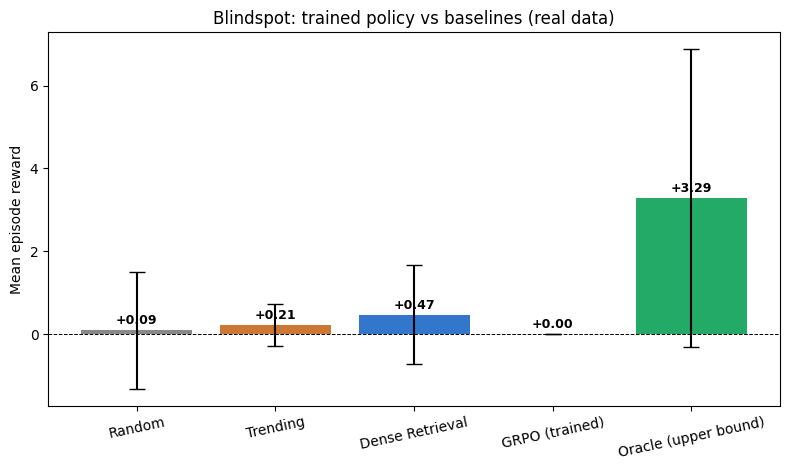

In [14]:
# 4.4 Trained policy vs baselines vs oracle — bar chart.
import json, matplotlib.pyplot as plt
pretrain = json.load(open('blindspot-env/plots/summary_pretraining.json'))
trained_all_row = {
    'name': 'GRPO (trained)',
    'eval_slice': 'all_users',
    'total': float(df_trained['total'].mean()),
    'std': float(df_trained['total'].std()),
    'adoption': float(df_trained.get('adoption', pd.Series([0])).mean()),
    'novelty': float(df_trained.get('novelty', pd.Series([0])).mean()),
    'onboarding': float(df_trained.get('onboarding', pd.Series([0])).mean()),
    'efficiency': float(df_trained.get('efficiency', pd.Series([0])).mean()),
    'false_positive': float(df_trained.get('false_positive', pd.Series([0])).mean()),
}
trained_heldout_row = {
    'name': 'GRPO (trained)',
    'eval_slice': 'held_out',
    'total': float(df_trained_heldout['total'].mean()),
    'std': float(df_trained_heldout['total'].std()),
    'adoption': float(df_trained_heldout.get('adoption', pd.Series([0])).mean()),
    'novelty': float(df_trained_heldout.get('novelty', pd.Series([0])).mean()),
    'onboarding': float(df_trained_heldout.get('onboarding', pd.Series([0])).mean()),
    'efficiency': float(df_trained_heldout.get('efficiency', pd.Series([0])).mean()),
    'false_positive': float(df_trained_heldout.get('false_positive', pd.Series([0])).mean()),
}
all_rows = list(pretrain) + [trained_all_row]
# Reorder: baselines then trained then oracle
ordered = ['Random','Trending','Dense Retrieval','GRPO (trained)','Oracle (upper bound)']
all_rows.sort(key=lambda r: ordered.index(r['name']) if r['name'] in ordered else 99)

fig, ax = plt.subplots(figsize=(8, 4.8))
names  = [r['name'] for r in all_rows]
totals = [r['total'] for r in all_rows]
stds   = [r['std'] for r in all_rows]
colors = ['#888888','#cc7733','#3377cc','#cc3377','#22aa66']
bars = ax.bar(names, totals, yerr=stds, capsize=6, color=colors[:len(names)])
for i, t in enumerate(totals):
    ax.text(i, t + 0.15, f'{t:+.2f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_ylabel('Mean episode reward')
ax.set_title('Blindspot: trained policy vs baselines (real data)')
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig('blindspot-env/plots/comparison_with_trained.png', dpi=130, bbox_inches='tight')
plt.show()

# Save updated summaries: all-user comparison plus held-out trained evidence.
with open('blindspot-env/plots/summary_with_trained.json','w') as f:
    json.dump(all_rows, f, indent=2)
with open('blindspot-env/plots/summary_heldout_with_trained.json','w') as f:
    json.dump(trained_heldout_row, f, indent=2)

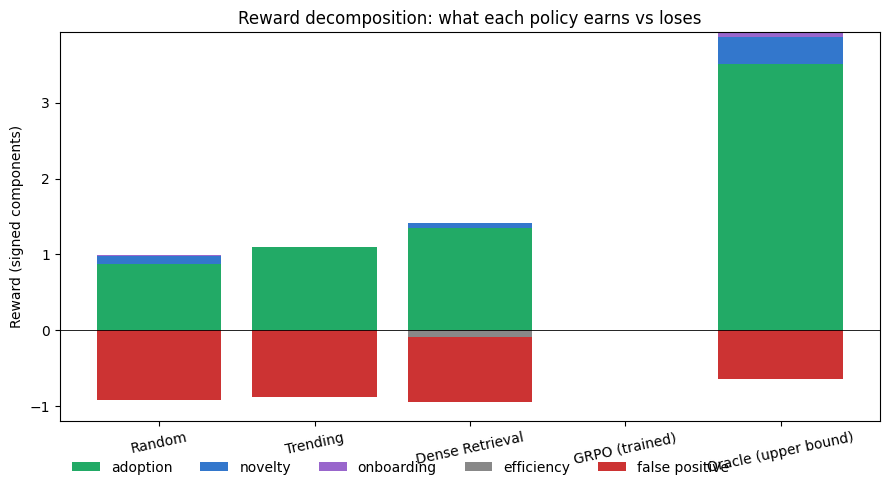

In [15]:
# 4.5 Reward decomposition stacked bar — what does GRPO win on?
import matplotlib.pyplot as plt, numpy as np
components = ['adoption','novelty','onboarding','efficiency','false_positive']
palette = {'adoption':'#22aa66','novelty':'#3377cc','onboarding':'#9966cc',
           'efficiency':'#888888','false_positive':'#cc3333'}

fig, ax = plt.subplots(figsize=(9, 5))
bottom_pos = np.zeros(len(all_rows)); bottom_neg = np.zeros(len(all_rows))
for c in components:
    vals = np.array([r.get(c, 0.0) for r in all_rows])
    bot = np.where(vals>=0, bottom_pos, bottom_neg)
    ax.bar(names, vals, bottom=bot, color=palette[c], label=c.replace('_',' '))
    bottom_pos += np.where(vals>=0, vals, 0)
    bottom_neg += np.where(vals< 0, vals, 0)
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('Reward (signed components)')
ax.set_title('Reward decomposition: what each policy earns vs loses')
ax.legend(ncol=5, frameon=False, loc='upper left', bbox_to_anchor=(0,-0.07))
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig('blindspot-env/plots/decomposition_with_trained.png', dpi=130, bbox_inches='tight')
plt.show()

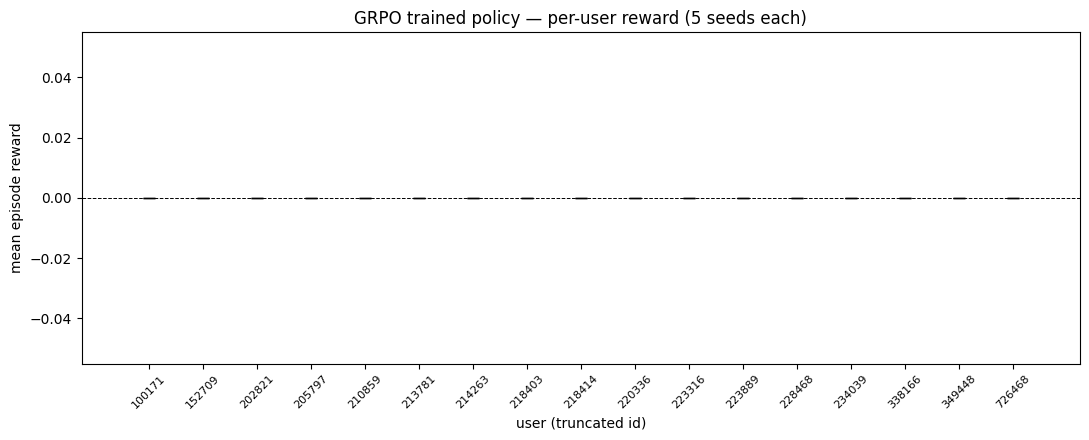

  users with positive mean : 0/17


In [16]:
# 4.6 Per-user reward — does training help all users equally?
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.5))
agg = df_trained.groupby('user')['total'].agg(['mean','std']).sort_values('mean')
ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'], capsize=4,
       color=['#cc3333' if x<0 else '#22aa66' for x in agg['mean']])
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_xticks(range(len(agg))); ax.set_xticklabels([str(u)[:6] for u in agg.index], rotation=45, fontsize=8)
ax.set_ylabel('mean episode reward'); ax.set_xlabel('user (truncated id)')
ax.set_title('GRPO trained policy — per-user reward (5 seeds each)')
plt.tight_layout()
plt.savefig('blindspot-env/plots/per_user_reward.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'  users with positive mean : {(agg["mean"]>0).sum()}/{len(agg)}')

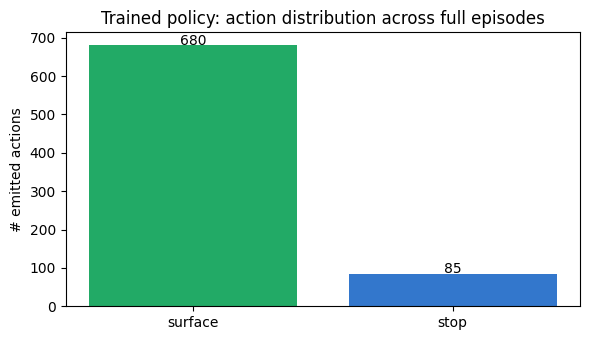

In [17]:
# 4.7 Action-type distribution — what is the trained policy actually doing across full episodes?
import matplotlib.pyplot as plt
import pandas as pd

flat_actions = [action for actions in df_trained['actions'] for action in (actions or [])]
counts = pd.Series(flat_actions).value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(counts.index, counts.values, color=['#22aa66', '#3377cc', '#cc7733', '#888888'][:len(counts)])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center')
ax.set_ylabel('# emitted actions')
ax.set_title('Trained policy: action distribution across full episodes')
plt.tight_layout()
plt.savefig('blindspot-env/plots/action_type_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# 4.8 Sample qualitative episodes — show a few full prompt → action-trace → reward cases.
import textwrap
import pandas as pd

sample = df_trained.sort_values('total', ascending=False).head(3)
for _, row in sample.iterrows():
    print('=' * 70)
    print(f'user={row["user"]}  seed={row["seed"]}  reward={row["total"]:+.2f}  steps={row["num_steps"]}')
    print(f'actions: {row["action_trace"]}')
    print('completions:')
    print(textwrap.fill(row['completion'][:500], width=70, initial_indent='  ', subsequent_indent='  '))
print('\n— and the worst three —')
for _, row in df_trained.sort_values('total').head(3).iterrows():
    print('=' * 70)
    print(f'user={row["user"]}  seed={row["seed"]}  reward={row["total"]:+.2f}  steps={row["num_steps"]}')
    print(f'actions: {row["action_trace"]}')
    print(textwrap.fill(row['completion'][:500], width=70, initial_indent='  ', subsequent_indent='  '))

user=10017193  seed=0  reward=+0.00  steps=9
actions: surface -> surface -> surface -> surface -> surface -> surface -> surface -> surface -> stop
completions:
  { "type": "surface", "concept_id": 1 }  { "type": "surface",
  "concept_id": 1 }  { "type": "surface", "concept_id": 1 }  { "type":
  "surface", "concept_id": 1 }  { "type": "surface", "concept_id": 1 }
  { "type": "surface", "concept_id": 1 }  { "type": "surface",
  "concept_id": 1 }  { "type": "surface", "concept_id": 1 }  {"type":
  "stop"}  # auto-stop after rollout limit
user=10017193  seed=1  reward=+0.00  steps=9
actions: surface -> surface -> surface -> surface -> surface -> surface -> surface -> surface -> stop
completions:
  { "type": "surface", "concept_id": 1 }  { "type": "surface",
  "concept_id": 1 }  { "type": "surface", "concept_id": 1 }  { "type":
  "surface", "concept_id": 1 }  { "type": "surface", "concept_id": 1 }
  { "type": "surface", "concept_id": 1 }  { "type": "surface",
  "concept_id": 1 }  { "type": 

In [19]:
# 4.9 Headline summary table.
import pandas as pd
rows = []
for r in all_rows:
    rows.append({
        'policy': r['name'],
        'eval_slice': 'all_users',
        'mean_reward': round(r['total'], 3),
        'std': round(r['std'], 3),
        'adoption': round(r.get('adoption', 0), 2),
        'novelty': round(r.get('novelty', 0), 2),
        'onboarding': round(r.get('onboarding', 0), 2),
        'false_positive': round(r.get('false_positive', 0), 2),
    })
rows.append({
    'policy': 'GRPO (trained)',
    'eval_slice': 'held_out',
    'mean_reward': round(float(df_trained_heldout['total'].mean()), 3),
    'std': round(float(df_trained_heldout['total'].std()), 3),
    'adoption': round(float(df_trained_heldout.get('adoption', pd.Series([0])).mean()), 2),
    'novelty': round(float(df_trained_heldout.get('novelty', pd.Series([0])).mean()), 2),
    'onboarding': round(float(df_trained_heldout.get('onboarding', pd.Series([0])).mean()), 2),
    'false_positive': round(float(df_trained_heldout.get('false_positive', pd.Series([0])).mean()), 2),
})
summary_df = pd.DataFrame(rows)

# % of oracle gap closed by trained policy (vs best baseline)
import json
trained_r = next(r for r in all_rows if r['name']=='GRPO (trained)')['total']
heldout_r = float(df_trained_heldout['total'].mean())
oracle_r  = next(r for r in all_rows if r['name'].startswith('Oracle'))['total']
best_baseline_r = max(r['total'] for r in all_rows
                      if r['name'] in ('Random','Trending','Dense Retrieval'))
gap_total  = oracle_r - best_baseline_r
gap_closed = trained_r - best_baseline_r
pct = (gap_closed / gap_total * 100) if gap_total > 0 else 0

print('\nTRAINED-POLICY HEADLINE')
print('='*42)
print(f'  best baseline reward : {best_baseline_r:+.3f}')
print(f'  trained reward       : {trained_r:+.3f}  (all users)')
print(f'  held-out reward      : {heldout_r:+.3f}  ({len(test_users)} users, 5 seeds each)')
print(f'  oracle reward        : {oracle_r:+.3f}')
print(f'  gap closed           : {pct:.1f}% of (oracle - best-baseline)')
display(summary_df)


TRAINED-POLICY HEADLINE
  best baseline reward : +0.467
  trained reward       : +0.000  (all users)
  held-out reward      : +0.000  (4 users, 5 seeds each)
  oracle reward        : +3.286
  gap closed           : -16.6% of (oracle - best-baseline)


,policy,eval_slice,mean_reward,std,adoption,novelty,onboarding,false_positive
0,Random,all_users,0.088,1.404,0.88,0.10,0.02,-0.91
1,Trending,all_users,0.212,0.510,1.09,0.00,0.00,-0.88
2,Dense Retrieval,all_users,0.467,1.201,1.35,0.06,0.00,-0.86
3,GRPO (trained),all_users,0.000,0.000,0.00,0.00,0.00,0.00
4,Oracle (upper bound),all_users,3.286,3.588,3.51,0.35,0.07,-0.64
5,GRPO (trained),held_out,0.000,0.000,0.00,0.00,0.00,0.00


---
## 5. (Optional) Push adapter to the Hugging Face Hub

In [ ]:
# from huggingface_hub import login; login()
# model.push_to_hub('vasarlalikhilavinash/blindspot-qwen35-9b-grpo')